In [5]:
# importing libraries + utils.py functions, setting up reproducible randomness, and defining paths to train and test data
import os
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt
import sys

sys.path.append('..')
from config import DATA_PATH
from pathlib import Path
from utils import (
    find_audio_file,
    load_audio,
    bandpass_filter,
    load_spectrogram,
    quick_spectrogram,
    get_main_freq_traj,
    track_ridge_tfridge_like,
    show_spectrogram_batch,
    get_cv_freq_traj
)
np.random.seed(0)

TRAIN_PATH = Path(DATA_PATH) / "train"
TEST_PATH = Path(DATA_PATH) / "test"

import importlib
import utils
importlib.reload(utils)


<module 'utils' from '/Users/netrakhot/mouse_vocalization_2026/data_prep/utils.py'>

In [6]:
# finds all .WAV files in the training and test folders and stores names + splits + paths in a DataFrame
splits = {"train": TRAIN_PATH, "test": TEST_PATH}
file_records = []

for split_name, split_path in splits.items():
    wavs = list(split_path.glob("*.WAV"))
    for wav_path in wavs:
        file_records.append({
            "filename": wav_path.name,
            "split": split_name,
            "full_path": wav_path,
        })

file_df = pd.DataFrame(file_records)

print(file_df["split"].value_counts())
print(f"Total .WAV files: {len(file_df)}")

split
train    20264
test      2251
Name: count, dtype: int64
Total .WAV files: 22515


In [ ]:
# samples n_sample audio files and summarizes their sample rates + channel counts + durations for each data split
n_sample = 200
sample_df = file_df.sample(n=min(n_sample, len(file_df)), random_state=0)

info_rows = []
for _, row in sample_df.iterrows():
    info = sf.info(row["full_path"])
    info_rows.append({
        "filename": row["filename"],
        "split": row["split"],
        "samplerate": info.samplerate,
        "duration_s": info.duration,
        "channels": info.channels,
    })

info_df = pd.DataFrame(info_rows)
print("Unique sample rates found (Hz):", info_df["samplerate"].unique())
print("Unique channel counts found:", info_df["channels"].unique())
print(info_df.groupby("split")["duration_s"].describe())

Unique sample rates found (Hz): [250000]
Unique channel counts found: [1]
       count      mean       std       min       25%       50%       75%  \
split                                                                      
test    22.0  0.052222  0.031765  0.017604  0.034804  0.043204  0.054004   
train  178.0  0.060355  0.031673  0.009604  0.036804  0.054404  0.075204   

            max  
split            
test   0.147204  
train  0.172804  


In [ ]:
# checks n_check audio files for near-silent recordings or errors during loading and band-pass filtering, then marks any flagged files
n_check = 500
check_df = file_df.sample(n=min(n_check, len(file_df)), random_state=1)

issues = []
silence_thresh = 1e-4 # this num is the maximum amplitude threshold to consider a recording as almost silent

for _, row in check_df.iterrows():
    try:
        a, s = load_audio(row["full_path"])
        if np.abs(a).max() < silence_thresh:
            issues.append({"filename": row["filename"], "split": row["split"], "issue": "near-silent"})
            continue
        _ = bandpass_filter(a, s, LOW_HZ_TYPICAL, HIGH_HZ_TYPICAL)
    except Exception as e:
        issues.append({"filename": row["filename"], "split": row["split"], "issue": f"error: {e}"})

issues_df = pd.DataFrame(issues)
print(f"Checked {len(check_df)} files, found {len(issues_df)} issues")
if len(issues_df) > 0:
    print(issues_df.groupby("split")["issue"].value_counts())
    issues_df.to_csv("flagged_files.csv", index=False)

Checked 500 files, found 500 issues
split  issue                                      
test   error: name 'LOW_HZ_TYPICAL' is not defined     44
train  error: name 'LOW_HZ_TYPICAL' is not defined    456
Name: count, dtype: int64


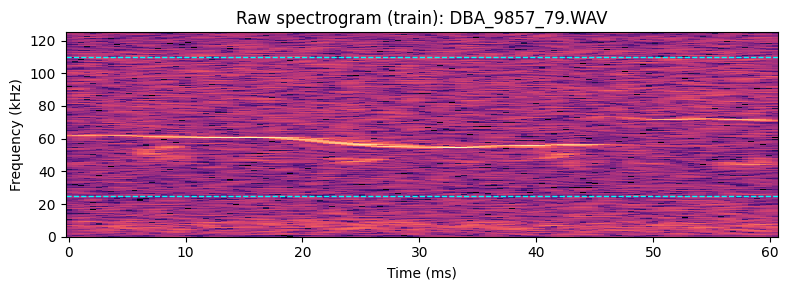

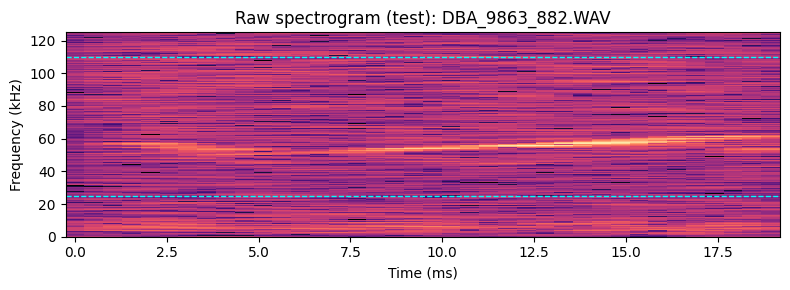

In [ ]:
# checking if the audio files are already filtered / what raw files look like
for split_name in ["train", "test"]:
    sample_row = file_df[file_df["split"] == split_name].sample(1, random_state=2).iloc[0]

    a, s = load_audio(sample_row["full_path"])

    S_db, freqs, times_bg = quick_spectrogram(
        a,
        s,
        n_fft=1024, # frequency resolution of the spectrogram
        hop_length=128, # this basically controls the time spacing between each spectrogram frame
    )

    plt.figure(figsize=(8, 3))
    plt.pcolormesh(times_bg * 1000, freqs / 1000, S_db, shading="auto", cmap="magma", vmin=-60, vmax=0)
    plt.ylim(0, 125)
    plt.axhline(25, color="cyan", linestyle="--", linewidth=1) # lower boundary of expected USV freq range
    plt.axhline(110, color="cyan", linestyle="--", linewidth=1) # upper boundary of expected USV freq range
    plt.title(f"Raw spectrogram ({split_name}): {sample_row['filename']}")
    plt.xlabel("Time (ms)")
    plt.ylabel("Frequency (kHz)")
    plt.tight_layout()
    plt.show()

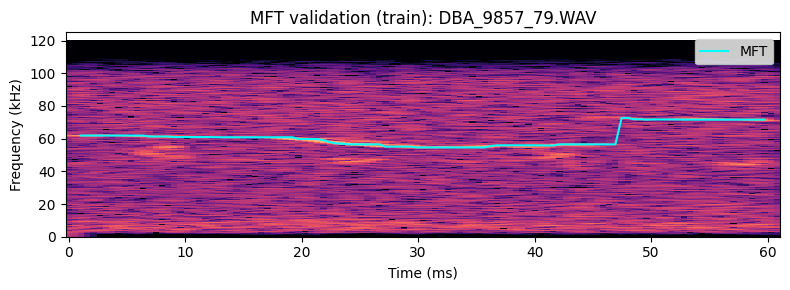

Detected active bins: 111 / 115


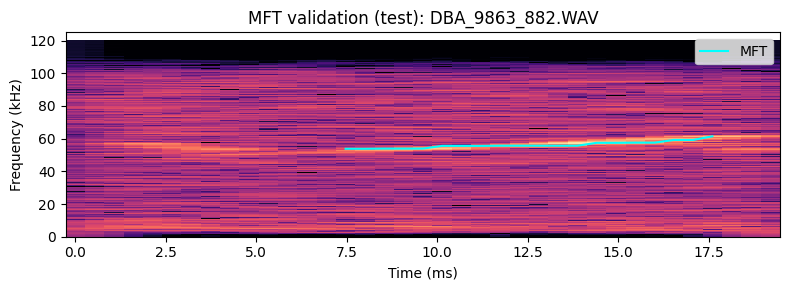

Detected active bins: 20 / 37


In [ ]:
# overlays the extracted MFT on a filtered spectrogram from each split to visually check its accuracy
for split_name in ["train", "test"]:
    sample_row = file_df[file_df["split"] == split_name].sample(1, random_state=2).iloc[0]
    path = sample_row["full_path"]

    a, s = load_audio(path, target_sr=240000)
    filtered = bandpass_filter(a, s, low_hz=2500, high_hz=100000, order=3)

    S_db, freqs, times_bg = quick_spectrogram(filtered, s)

    times_traj, freq_traj, active_bins = get_main_freq_traj(path)

    plot_freq = np.where(freq_traj > 0, freq_traj, np.nan) # replaces inactive frequencies with NaN so they're not connected or plotted

    plt.figure(figsize=(8, 3))
    plt.pcolormesh(times_bg * 1000, freqs / 1000, S_db, shading="auto", cmap="magma", vmin=-60, vmax=0)
    plt.plot(times_traj * 1000, plot_freq / 1000, color="cyan", linewidth=1.5, label="MFT")

    plt.ylim(0, 125)
    plt.xlabel("Time (ms)")
    plt.ylabel("Frequency (kHz)")
    plt.title(f"MFT validation ({split_name}): {sample_row['filename']}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Detected active bins:", active_bins.sum(), "/", len(active_bins))

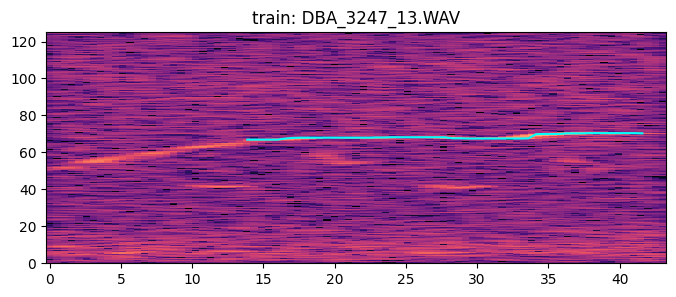

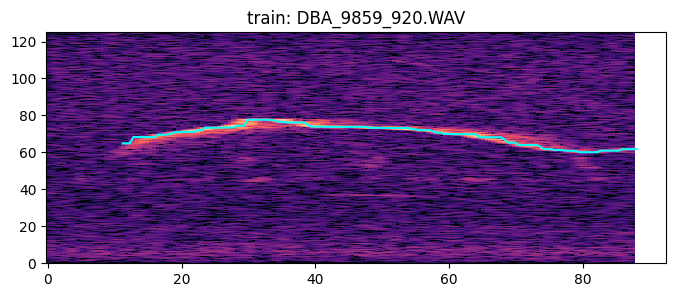

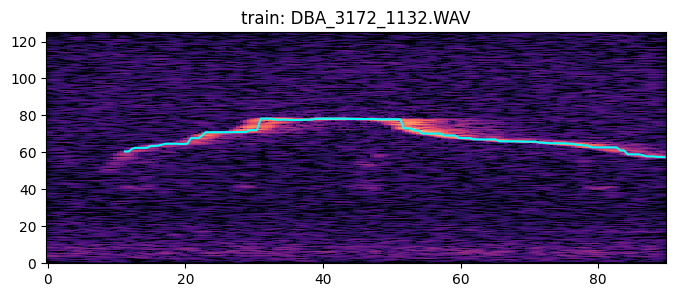

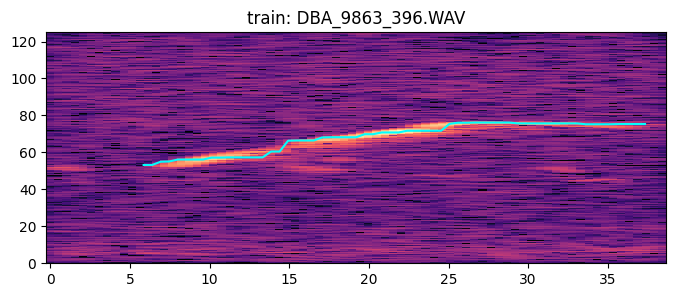

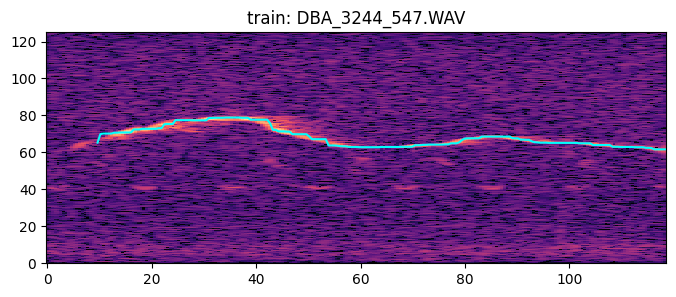

In [40]:
sample_check = file_df.sample(5, random_state=1)

for _, row in sample_check.iterrows():
    path = row["full_path"]

    a, s = load_audio(path)
    S_db, freqs, times_bg = quick_spectrogram(a, s)

    times_traj, freq_traj, active_bins = get_main_freq_traj(path)
    plot_freq = np.where(freq_traj > 0, freq_traj, np.nan)

    plt.figure(figsize=(8, 3))
    plt.pcolormesh(times_bg*1000, freqs/1000, S_db, shading="auto", cmap="magma", vmin=-60, vmax=0)
    plt.plot(times_traj*1000, plot_freq/1000, color="cyan", linewidth=1.5)
    plt.ylim(0, 125)
    plt.title(f"{row['split']}: {row['filename']}")
    plt.show()

In [ ]:
# see 20 spectrograms at a time to inspect usv types
batch_number = 4
shown_files = show_spectrogram_batch(file_df, batch_number)

In [ ]:
# checks all the audio files to see if they're good quality to be analyzed (not too much silence/noise, less errors when loading or filtering the files)
audio_files = file_df["full_path"].tolist()

flagged = []

for path in audio_files:
    reasons = utils.check_mft_quality(path)

    # basically flags any files that have the issues in the top comment
    if reasons: # Only flags the file when at least one quality issue was detected
        flagged.append({
            "file": Path(path).name,
            "reasons": reasons, #returns a list of quality issues found in the MFT of that file
        })

flagged_df = pd.DataFrame(flagged)

print(flagged_df.head())
print(f"Flagged {len(flagged_df)} files")

/Users/netrakhot/mouse_vocalization_2026/.venv/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1921
  warnings.warn(


                file       reasons
0  DBA_3172_1197.WAV  [no_contour]
1   DBA_3246_348.WAV  [no_contour]
2   DBA_9859_133.WAV  [no_contour]
3  DBA_9859_1293.WAV  [no_contour]
4   DBA_3247_403.WAV  [no_contour]
Flagged 870 files


In [ ]:
# randomly sample 30 files with no_contour
sample_no_contour = flagged_df[
    flagged_df["reasons"].astype(str).str.contains("no_contour")
].sample(30, random_state=2)

sample_no_contour

In [ ]:
# filters out files flagged only for having no contour so remaining MFT quality issues can be looked at separately
other_flags = flagged_df[
    ~flagged_df["reasons"].astype(str).str.contains("no_contour") # ~ reverses the condition, keeping rows that do not mention "no_contour" and discarding those that do
].copy()  # creates a separate DataFrame that can be safely modified later so the main data folder isn't affected 

print(f"Non-no_contour flags: {len(other_flags)}")
other_flags.head()

Non-no_contour flags: 216


,file,reasons
7,DBA_9859_1330.WAV,[too_short]
10,DBA_9858_297.WAV,[too_short]
13,DBA_9863_1058.WAV,[too_short]
15,DBA_9859_1443.WAV,[too_short]
19,DBA_3244_258.WAV,"[jump_reversal, multiple_nearby_jumps]"


In [ ]:
# these r files with abrupt frequency-direction reversals
jump_reversal_files = other_flags[
    other_flags["reasons"].astype(str).str.contains("jump_reversal")
]

# files with multiple nearby frequency jumps
multiple_jump_files = other_flags[
    other_flags["reasons"].astype(str).str.contains("multiple_nearby_jumps")
]

# files with frequency contours contain NaN values
nan_files = other_flags[
    other_flags["reasons"].astype(str).str.contains("contains_nan")
]

# files with contours that are too short for good analysis
short_files = other_flags[
    other_flags["reasons"].astype(str).str.contains("too_short")
]

In [ ]:
# this cell randomly chooses up to 20 files with jump-reversal warnings for inspection
sample_jump_reversal = jump_reversal_files.sample(
    n=min(20, len(jump_reversal_files)),
    random_state=0,
)

sample_jump_reversal

,file,reasons
515,DBA_3241_403.WAV,"[jump_reversal, multiple_nearby_jumps]"
587,DBA_9857_757.WAV,"[jump_reversal, multiple_nearby_jumps]"
415,DBA_3243_299.WAV,[jump_reversal]
402,DBA_3241_405.WAV,[jump_reversal]
326,DBA_3241_232.WAV,[jump_reversal]
482,DBA_3170_528.WAV,[jump_reversal]
540,DBA_3171_1587.WAV,"[jump_reversal, multiple_nearby_jumps]"
300,DBA_3171_914.WAV,"[jump_reversal, multiple_nearby_jumps]"
536,DBA_3243_869.WAV,[jump_reversal]
58,DBA_3172_682.WAV,"[jump_reversal, multiple_nearby_jumps]"


In [ ]:
# makes names for all files flagged for having no contour so they can be excluded from the other flagged files
no_contour_files = set(
    flagged_df[
        flagged_df["reasons"].astype(str).str.contains("no_contour")
    ]["file"]
)

In [ ]:
# makes a nice cleaned file list by removing audio files with no detected mft contour
clean_file_df = file_df[
    ~file_df["filename"].isin(no_contour_files)
].copy()

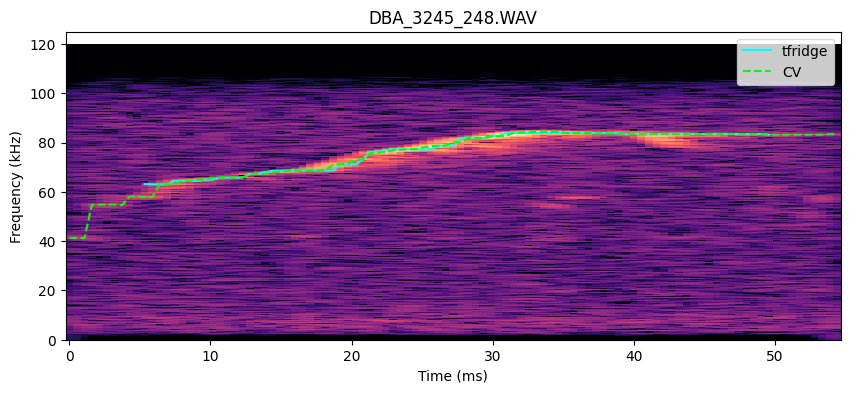

In [27]:
path = file_df.iloc[1]["full_path"]

# Existing tfridge method
old_result = utils.get_main_freq_traj(path)
times_old, freq_old = old_result[:2]

# Computer-vision method
times_cv, freq_cv, amp_cv = utils.get_cv_freq_traj(path)

# Background spectrogram
audio, sr = utils.load_audio(path, target_sr=240000)
audio = utils.bandpass_filter(audio, sr)
S_db, freqs, times = utils.quick_spectrogram(audio, sr)

plt.figure(figsize=(10, 4))
plt.pcolormesh(times * 1000, freqs / 1000, S_db,
               shading="auto", cmap="magma", vmin=-60, vmax=0)

plt.plot(times_old * 1000, freq_old / 1000,
         color="cyan", label="tfridge")
plt.plot(times_cv * 1000, freq_cv / 1000,
         color="lime", linestyle="--", label="CV")

plt.ylim(0, 125)
plt.xlabel("Time (ms)")
plt.ylabel("Frequency (kHz)")
plt.title(Path(path).name)
plt.legend()
plt.show()